In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

snapshot = pd.read_csv(
    "/content/d2c_churn_data/d2c churn data package/rfm_modeling_snapshot.csv"
)

snapshot.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [15]:
snapshot.shape
snapshot.info()
snapshot.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

,0
customer_id,0
snapshot_date,0
city_tier,0
age_group,0
acquisition_channel,0
loyalty_tier,1386
preferred_category,0
marketing_consent,0
recency_days,0
frequency_180d,0


In [16]:
snapshot["R_score"] = pd.qcut(
    snapshot["recency_days"],
    5,
    labels=[5,4,3,2,1]
)

In [17]:
snapshot["F_score"] = pd.qcut(
    snapshot["frequency_180d"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [18]:
snapshot["M_score"] = pd.qcut(
    snapshot["monetary_180d"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [19]:
snapshot["RFM_score"] = (
    snapshot["R_score"].astype(int)
    + snapshot["F_score"].astype(int)
    + snapshot["M_score"].astype(int)
)

### Additional Behavioural Signals

In [21]:
snapshot[[
    "ticket_count_90d",
    "negative_ticket_rate_90d",
    "sessions_30d",
    "campaign_clicks_30d",
    "return_rate_180d"
]].describe()

,ticket_count_90d,negative_ticket_rate_90d,sessions_30d,campaign_clicks_30d,return_rate_180d
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,0.229167,0.138819,5.460000,0.649583,0.061505
std,0.471779,0.343293,4.400167,0.951579,0.203092
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,0.000000,0.000000
50%,0.000000,0.000000,5.000000,0.000000,0.000000
75%,0.000000,0.000000,8.000000,1.000000,0.000000
max,3.000000,1.000000,25.000000,6.000000,1.000000


In [22]:
snapshot.groupby(
    "churn_next_60d"
)[
    "ticket_count_90d"
].mean()

,ticket_count_90d
churn_next_60d,
0,0.296936
1,0.152618


In [23]:
snapshot.groupby(
    "churn_next_60d"
)[
    "negative_ticket_rate_90d"
].mean()

,negative_ticket_rate_90d
churn_next_60d,
0,0.162346
1,0.112245


###Observation

Support activity does not appear to be a major churn driver in this dataset.

Retained customers actually generated more support tickets and slightly higher negative ticket rates than churned customers.

One possible explanation is that engaged customers continue interacting with the brand and seek support when issues occur, whereas customers who are already disengaging may simply stop interacting altogether.

Support metrics may still be useful for customer segmentation but do not appear to be strong standalone churn indicators.

In [24]:
snapshot.groupby(
    "churn_next_60d"
)["campaign_clicks_30d"].mean()

,campaign_clicks_30d
churn_next_60d,
0,0.736057
1,0.551908


In [25]:
snapshot.groupby(
    "churn_next_60d"
)["return_rate_180d"].mean()

,return_rate_180d
churn_next_60d,
0,0.048381
1,0.076328


## Customer Segmentation

In [26]:
snapshot["R_score"] = pd.qcut(
    snapshot["recency_days"],
    5,
    labels=[5,4,3,2,1]
)

snapshot["F_score"] = pd.qcut(
    snapshot["frequency_180d"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

snapshot["M_score"] = pd.qcut(
    snapshot["monetary_180d"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

snapshot["RFM_score"] = (
    snapshot["R_score"].astype(int)
    + snapshot["F_score"].astype(int)
    + snapshot["M_score"].astype(int)
)

snapshot["RFM_score"].describe()

,RFM_score
count,2400.000000
mean,9.012500
std,3.509389
min,3.000000
25%,7.000000
50%,9.000000
75%,12.000000
max,15.000000


In [27]:
def assign_segment(row):

    # Champions
    if (
        row["RFM_score"] >= 13
        and row["sessions_30d"] >= snapshot["sessions_30d"].median()
    ):
        return "Champion"

    # High Value Unhappy
    elif (
        row["monetary_180d"] >= snapshot["monetary_180d"].quantile(0.75)
        and row["ticket_count_90d"] >= 1
    ):
        return "High Value Unhappy"

    # Loyal Customers
    elif row["RFM_score"] >= 10:
        return "Loyal Customer"

    # Discount Sensitive
    elif (
        row["avg_discount_pct_180d"]
        >= snapshot["avg_discount_pct_180d"].quantile(0.75)
    ):
        return "Discount Sensitive"

    # At Risk
    elif (
        row["recency_days"]
        >= snapshot["recency_days"].quantile(0.75)
    ):
        return "At Risk"

    # Dormant
    else:
        return "Dormant"

In [28]:
snapshot["segment_name"] = snapshot.apply(
    assign_segment,
    axis=1
)

In [29]:
snapshot["segment_name"].value_counts()

,count
segment_name,
Loyal Customer,708
At Risk,482
Dormant,443
Discount Sensitive,344
Champion,330
High Value Unhappy,93


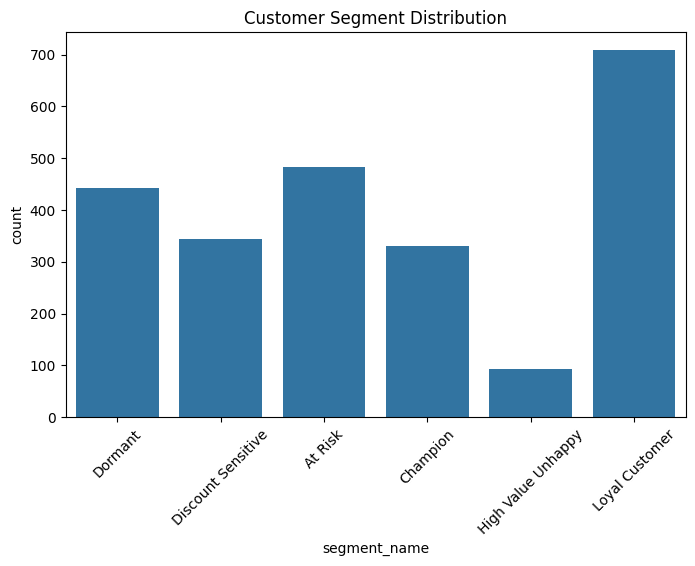

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=snapshot,
    x="segment_name"
)

plt.xticks(rotation=45)
plt.title("Customer Segment Distribution")
plt.show()

In [31]:
snapshot.groupby(
    "segment_name"
)["churn_next_60d"].mean().sort_values()

,churn_next_60d
segment_name,
Champion,0.066667
High Value Unhappy,0.225806
Loyal Customer,0.295198
Dormant,0.494357
Discount Sensitive,0.642442
At Risk,0.902490


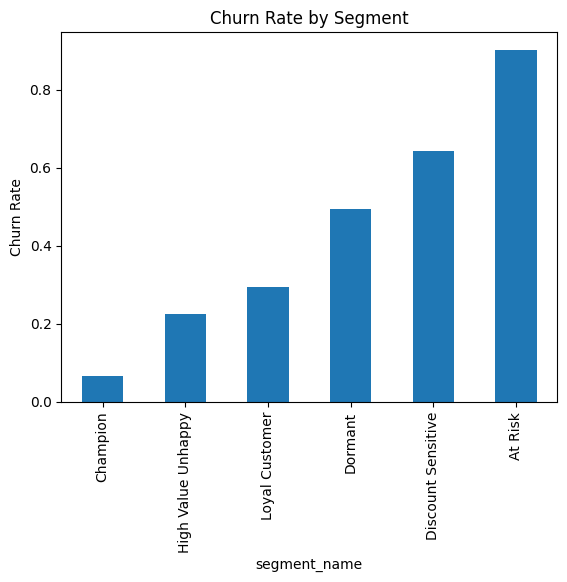

In [32]:
snapshot.groupby(
    "segment_name"
)["churn_next_60d"].mean().sort_values().plot(
    kind="bar"
)

plt.title("Churn Rate by Segment")
plt.ylabel("Churn Rate")
plt.show()

###Observation

The churn rate varies substantially across customer segments.

Champion and Loyal Customer segments exhibit lower churn rates, indicating stronger engagement and customer value.

At Risk and Dormant customers display elevated churn rates and should be prioritized for retention interventions.

High Value Unhappy customers represent an important segment because losing them would have a significant revenue impact despite their relatively strong spending behavior.

In [33]:
snapshot.groupby(
    "segment_name"
)[[
    "recency_days",
    "frequency_180d",
    "monetary_180d",
    "sessions_30d",
    "churn_next_60d"
]].mean().round(2)

,recency_days,frequency_180d,monetary_180d,sessions_30d,churn_next_60d
segment_name,,,,,
At Risk,213.35,0.41,319.48,2.95,0.90
Champion,24.72,3.27,2565.42,9.60,0.07
Discount Sensitive,85.14,1.11,598.06,5.08,0.64
Dormant,65.24,1.07,683.29,5.58,0.49
High Value Unhappy,45.70,2.80,2506.35,3.72,0.23
Loyal Customer,51.23,2.02,1538.61,5.58,0.30


In [34]:
snapshot[
[
    "customer_id",
    "segment_name",
    "recency_days",
    "frequency_180d",
    "monetary_180d",
    "ticket_count_90d",
    "return_rate_180d",
    "sessions_30d",
    "campaign_clicks_30d"
]
].to_csv(
    "segments.csv",
    index=False
)

In [35]:
from google.colab import files
files.download("segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Final Segmentation Summary

Six customer segments were created using RFM metrics together with support, engagement, and return-related behavioral signals.

Additional signals used:

- ticket_count_90d
- sessions_30d
- campaign_clicks_30d
- return_rate_180d
- avg_discount_pct_180d

The resulting segments provide actionable customer groups that can be targeted using different retention strategies rather than applying the same intervention to all customers.